In [1]:
import pandas as pd

df = pd.read_csv("/content/Cleaned_Dataset .csv")

print(df.head())

   Customer_ID  Age  Monthly_Income  Credit_Score  Loan_Amount  \
0         1001   28           28278           690       178393   
1         1002   29           38434           829        95580   
2         1003   48           29165           565        99123   
3         1004   35           91237           563       344254   
4         1005   55           79987           662       285514   

   Previous_Loans Loan_Approved  
0               1            No  
1               4            No  
2               1            No  
3               1            No  
4               4            No  


In [2]:
df["Loan_Approved"] = df["Loan_Approved"].map({
    "Yes": 1,
    "No": 0
})

In [3]:
X = df.drop(["Customer_ID", "Loan_Approved"], axis=1)
y = df["Loan_Approved"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [6]:
y_pred = clf.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 1 0 0 0 0 1 1 0 1 1 0 0 0 1 0 1 0]


In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12  2]
 [ 0  6]]


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.75      1.00      0.86         6

    accuracy                           0.90        20
   macro avg       0.88      0.93      0.89        20
weighted avg       0.93      0.90      0.90        20



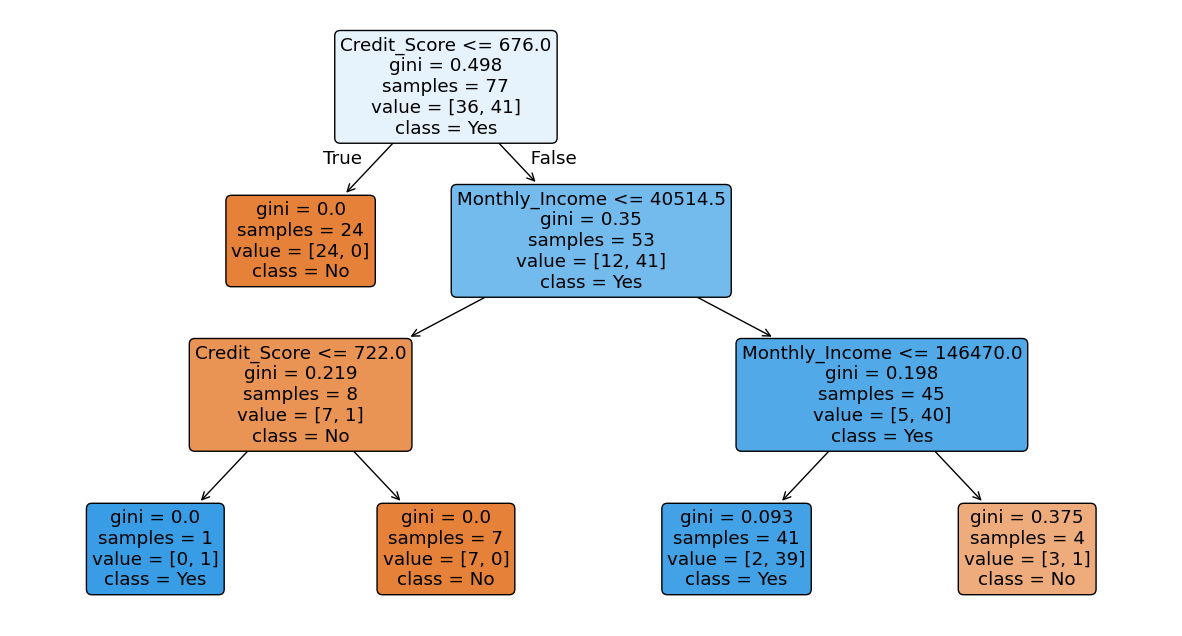

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))

plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)

plt.show()

In [15]:
from sklearn.metrics import accuracy_score, log_loss

In [16]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

results.append([
    criterion,
    depth,
    split_name,
    round(acc * 100, 2)
])

In [18]:
from sklearn.metrics import accuracy_score, log_loss

X = df.drop(["Customer_ID", "Loan_Approved"], axis=1)
y = df["Loan_Approved"]

results = []

splits = {
    "90:10": 0.10,
    "80:20": 0.20,
    "70:30": 0.30
}

depths = [3, 5, 7]

for criterion in ["gini", "entropy"]:

    for split_name, test_size in splits.items():

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=42
        )

        for depth in depths:

            model = DecisionTreeClassifier(
                criterion=criterion,
                max_depth=depth,
                random_state=42
            )

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)

            acc = accuracy_score(y_test, y_pred)
            loss = log_loss(y_test, y_prob)

            results.append([
                criterion,
                depth,
                split_name,
                round(acc * 100, 2),
                round(loss, 4)
            ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Criterion",
        "Max Depth",
        "Split",
        "Accuracy (%)",
        "Log Loss"
    ]
)

print(results_df)

   Criterion  Max Depth  Split  Accuracy (%)  Log Loss
0       gini          3  90:10         80.00    7.3041
1       gini          5  90:10         80.00    7.3304
2       gini          7  90:10         80.00    7.3304
3       gini          3  80:20         90.00    3.6625
4       gini          5  80:20         90.00    3.6806
5       gini          7  80:20         85.00    3.6998
6       gini          3  70:30         93.33    2.4502
7       gini          5  70:30         93.33    2.4537
8       gini          7  70:30         90.00    2.4666
9    entropy          3  90:10         50.00    7.5176
10   entropy          5  90:10         60.00   14.4734
11   entropy          7  90:10         60.00   14.4580
12   entropy          3  80:20         75.00    3.7896
13   entropy          5  80:20         75.00    7.2839
14   entropy          7  80:20         75.00    7.2839
15   entropy          3  70:30         83.33    2.5264
16   entropy          5  70:30         83.33    4.8560
17   entro